# Red Neuronal

In [2]:
from scipy import stats
import numpy as np

class capa():
  def __init__(self, n_neuronas_capa_anterior, n_neuronas, funcion_act):
    self.funcion_act = funcion_act
    self.b  = np.round(stats.truncnorm.rvs(-1, 1, loc=0, scale=1, size= n_neuronas).reshape(1,n_neuronas),3)
    self.W  = np.round(stats.truncnorm.rvs(-1, 1, loc=0, scale=1, size= n_neuronas * n_neuronas_capa_anterior).reshape(n_neuronas_capa_anterior,n_neuronas),3)


# Funcion de Activacion Sigmoide

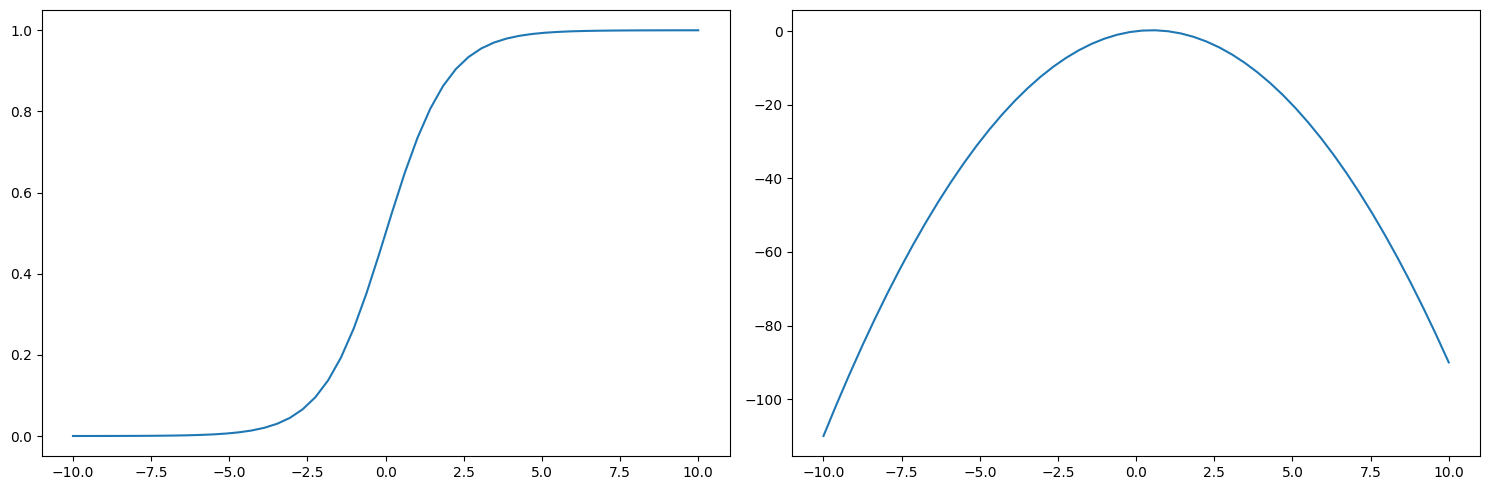

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Definimos la funcion sigmoide y su derivada
sigmoid = (
  lambda x:1 / (1 + np.exp(-x)),
  lambda x:x * (1 - x)
  )

# Generamos los datos
rango = np.linspace(-10,10).reshape([50,1])
datos_sigmoide = sigmoid[0](rango)
datos_sigmoide_derivada = sigmoid[1](rango)

#Cremos los graficos
fig, axes = plt.subplots(nrows=1, ncols=2, figsize =(15,5))
axes[0].plot(rango, datos_sigmoide)
axes[1].plot(rango, datos_sigmoide_derivada)
fig.tight_layout()


## Codificando una red neuronal

In [6]:
# Numero de neuronas en cada capa. 
# El primer valor es el numero de columnas de la capa de entrada.
neuronas = [2,4,8,1] 

# Funciones de activacion usadas en cada capa.
# Debe haber una funcion por cada conexion entre capas: len(neuronas)-1.
# Aquí replicamos la misma funcion sigmoid para todas las capas de salida.
funciones_activacion = [sigmoid] * (len(neuronas) - 1)


In [7]:
red_neuronal = []

for paso in range(len(neuronas)-1):
  x = capa(neuronas[paso],neuronas[paso+1],funciones_activacion[paso])
  red_neuronal.append(x)

print(red_neuronal)


[<__main__.capa object at 0x0000020436C95970>, <__main__.capa object at 0x00000204348ED070>, <__main__.capa object at 0x0000020436CFC170>]


## Prediccion

Para que la red neuronal prediga lo único que tenemos que hacer es definir los cáculos que tiene que seguir. 
Son 3 los cálculos a seguir: multiplicar los valores de entrada por la matriz de pesos W y sumar el parámetro bias (b) y aplicar la función de activación.

In [ ]:
# Para multiplicar los valores de entrada por la matriz de pesos tenemos que hacer una multiplicación matricial.

X =  np.round(np.random.randn(20,2),3) # Ejemplo de vector de entrada

z = X @ red_neuronal[0].W

print(z[:10,:], X.shape, z.shape)


[[-0.288489 -1.941212  2.692252 -1.003108]
 [ 0.141108  1.132731 -1.537045  0.634052]
 [ 0.108579  0.672484 -0.943428  0.332044]
 [ 0.235125  0.928261 -1.408483  0.305808]
 [ 0.222396 -0.07068  -0.192184 -0.453232]
 [-1.05111   0.288821  0.962677  2.106708]
 [-0.28152  -0.175452  0.561636  0.366384]
 [ 0.112536  0.682951 -0.960937  0.333156]
 [-0.656145  0.221309  0.551653  1.347192]
 [ 0.096828 -0.219029  0.142555 -0.344668]] (20, 2) (20, 4)


In [ ]:
# Sumamos el parámetro bias (b) al resultado anterior de z.

z = z + red_neuronal[0].b

print(z[:5,:])


[[ 0.503511 -2.504212  2.962252 -1.050108]
 [ 0.933108  0.569731 -1.267045  0.587052]
 [ 0.900579  0.109484 -0.673428  0.285044]
 [ 1.027125  0.365261 -1.138483  0.258808]
 [ 1.014396 -0.63368   0.077816 -0.500232]]


In [10]:
# Aplicamos la función de activación de esa capa.

a = red_neuronal[0].funcion_act[0](z)
a[:5,:]


array([[0.62328407, 0.07556343, 0.95083937, 0.25920436],
       [0.71770541, 0.6387011 , 0.21976352, 0.64268845],
       [0.71106847, 0.52734369, 0.33772968, 0.57078239],
       [0.73635814, 0.59031337, 0.24259899, 0.56434325],
       [0.73387957, 0.34667658, 0.51944419, 0.37748615]])

Con esto, tendríamos el resultado de la primera capa, que a su vez es la entrada para la segunda capa y así hasta la última. 
Por lo tanto, sto lo podemos definir de forma iterativa dentro de un bucle.

In [11]:
output = [X]

for num_capa in range(len(red_neuronal)):
  z = output[-1] @ red_neuronal[num_capa].W + red_neuronal[num_capa].b
  a = red_neuronal[num_capa].funcion_act[0](z)
  output.append(a)

print(output[-1])


[[0.66226706]
 [0.59714807]
 [0.60913309]
 [0.603784  ]
 [0.63086253]
 [0.61800534]
 [0.62846067]
 [0.60889093]
 [0.61705182]
 [0.63333477]
 [0.63789587]
 [0.61043828]
 [0.62388451]
 [0.60410894]
 [0.6395676 ]
 [0.61340101]
 [0.61785705]
 [0.6218804 ]
 [0.60836847]
 [0.64707025]]


# Creando la función de coste

Calculamos el error cuadrático: a cada valor predicho le restas el valor real, lo elevas al cuadrado, haces la suma ponderada y calculas su raíz. 
Además, esta misma función nos devuelva la derivada de la función de coste, la cual nos será útil en el paso de backpropagation.

In [12]:
def mse(Ypredich, Yreal):

  # Calculamos el error
  x = (np.array(Ypredich) - np.array(Yreal)) ** 2
  x = np.mean(x)

  # Calculamos la derivada de la funcion
  y = np.array(Ypredich) - np.array(Yreal)
  return (x,y)


Calculamos el error cuadrático medio.

In [13]:
from random import shuffle

Y = [0] * 10 + [1] * 10
shuffle(Y)
Y = np.array(Y).reshape(len(Y),1)

mse(output[-1], Y)[0]


0.26449846762485085

# Backpropagation: calculando el error en cada capa

In [ ]:
# Backpropagation: calculando el error en cada capa
# Obtenemos los pesos y bias de la capa de salida
red_neuronal[-1].b
red_neuronal[-1].W


array([[ 0.952],
       [-0.358],
       [ 0.98 ],
       [-0.609],
       [-0.914],
       [ 0.916],
       [ 0.287],
       [-0.281]])

In [ ]:
# Backprop en la ultima capa

a = output[-1]
x = mse(a,Y)[1] * red_neuronal[-2].funcion_act[1](a)

x


array([[-0.07554052],
       [ 0.14365129],
       [-0.09306149],
       [-0.09478631],
       [ 0.14691211],
       [-0.09017929],
       [-0.08675364],
       [ 0.14500297],
       [-0.09049022],
       [ 0.14707417],
       [-0.08364052],
       [-0.0926391 ],
       [ 0.14639614],
       [ 0.1444795 ],
       [ 0.14743369],
       [-0.09167817],
       [ 0.14588205],
       [-0.088913  ],
       [ 0.14494761],
       [ 0.14777165]])

Ahora usamos ese error para optimizar los valores de los parámetros mediante gradient descent

In [17]:
red_neuronal[-1].b = red_neuronal[-1].b - x.mean() * 0.01
red_neuronal[-1].W = red_neuronal[-1].W - (output[-1].T @ x) * 0.01

red_neuronal[-1].b
red_neuronal[-1].W


array([[ 0.94844724],
       [-0.36155276],
       [ 0.97644724],
       [-0.61255276],
       [-0.91755276],
       [ 0.91244724],
       [ 0.28344724],
       [-0.28455276]])

Entonces, si ponemos todo esto junto, la fórmula de backpropagation y gradient descent queda de la siguiente manera.

In [18]:
# Definimos el learning rate
lr = 0.05

# Creamos el indice inverso para ir de derecha a izquierda
back = list(range(len(output)-1))
back.reverse()

# Creamos el vector delta donde meteremos los errores en cada capa
delta = []

for capa in back:
  # Backprop #

  # Guardamos los resultados de la ultima capa antes de usar backprop para poder usarlas en gradient descent
  a = output[capa+1][1]

  # Backprop en la ultima capa 
  if capa == back[0]:
    x = mse(a,Y)[1] * red_neuronal[capa].funcion_act[1](a)
    delta.append(x)

  # Backprop en el resto de capas 
  else:
    x = delta[-1] @ W_temp * red_neuronal[capa].funcion_act[1](a)
    delta.append(x)

  # Guardamos los valores de W para poder usarlos en la iteracion siguiente
  W_temp = red_neuronal[capa].W.transpose()

  # Gradient Descent #

  # Ajustamos los valores de los parametros de la capa
  red_neuronal[capa].b = red_neuronal[capa].b - delta[-1].mean() * lr
  red_neuronal[capa].W = red_neuronal[capa].W - (output[capa].T @ delta[-1]) * lr


print('MSE: ' + str(mse(output[-1],Y)[0]) )
print('Estimacion: ' + str(output[-1]) )


MSE: 0.26449846762485085
Estimacion: [[0.66226706]
 [0.59714807]
 [0.60913309]
 [0.603784  ]
 [0.63086253]
 [0.61800534]
 [0.62846067]
 [0.60889093]
 [0.61705182]
 [0.63333477]
 [0.63789587]
 [0.61043828]
 [0.62388451]
 [0.60410894]
 [0.6395676 ]
 [0.61340101]
 [0.61785705]
 [0.6218804 ]
 [0.60836847]
 [0.64707025]]


## Entonces una vez realizado la red neuronal utilizamos un caso para poner a prueba la red neuronal

In [19]:
# CLASIFICACION DE PUNTOS

import random

def circulo(num_datos = 100,R = 1, minimo = 0,maximo= 1):
  pi = math.pi
  r = R * np.sqrt(stats.truncnorm.rvs(minimo, maximo, size= num_datos)) * 10
  theta = stats.truncnorm.rvs(minimo, maximo, size= num_datos) * 2 * pi *10

  x = np.cos(theta) * r
  y = np.sin(theta) * r

  y = y.reshape((num_datos,1))
  x = x.reshape((num_datos,1))

  #Vamos a reducir el numero de elementos para que no cause un Overflow
  x = np.round(x,3)
  y = np.round(y,3)

  df = np.column_stack([x,y])
  return(df)

Crearemos dos sets de datos aleatorios, cada uno de 150 puntos y con radios diferentes. 
La idea de hacer que los datos se creen de forma aleatoria es que puedan solaparse, de tal manera que la red neuronal le cueste un poco y el resultado no sea perfecto.

In [20]:
datos_1 = circulo(num_datos = 150, R = 2)
datos_2 = circulo(num_datos = 150, R = 0.5)
X = np.concatenate([datos_1,datos_2])
X = np.round(X,3)

Y = [0] * 150 + [1] * 150
Y = np.array(Y).reshape(len(Y),1)

Con esto tendríamos nuestros datos de entrada (X) y sus correspondientes etiquetas (Y). 
Teniendo esto en cuenta, visualizamos cómo es el problema que debe resolver nuestra red neuronal.

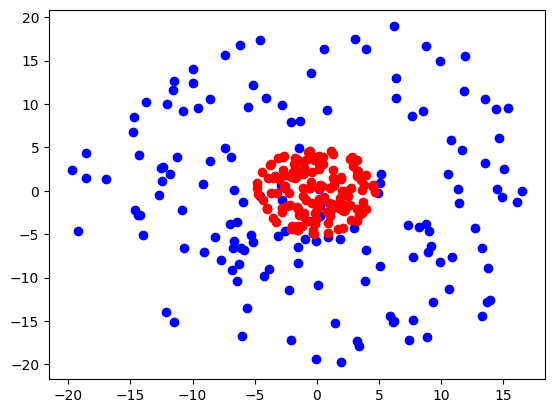

In [21]:
# Visualizamos los datos
plt.cla()
plt.scatter(X[0:150,0],X[0:150,1], c = "b")
plt.scatter(X[150:300,0],X[150:300,1], c = "r")
plt.show()


# Entrenamiento de nuestra red neuronal

In [22]:
def entrenamiento(X,Y, red_neuronal, lr = 0.01):

  # Output guardara el resultado de cada capa
  # En la capa 1, el resultado es el valor de entrada
  output = [X]

  for num_capa in range(len(red_neuronal)):
    z = output[-1] @ red_neuronal[num_capa].W + red_neuronal[num_capa].b

    a = red_neuronal[num_capa].funcion_act[0](z)

    # Incluimos el resultado de la capa a output
    output.append(a)

  # Backpropagation

  back = list(range(len(output)-1))
  back.reverse()

  # Guardaremos el error de la capa en delta  
  delta = []

  for capa in back:
    # Backprop #delta

    a = output[capa+1]

    if capa == back[0]:
      x = mse(a,Y)[1] * red_neuronal[capa].funcion_act[1](a)
      delta.append(x)

    else:
      x = delta[-1] @ W_temp * red_neuronal[capa].funcion_act[1](a)
      delta.append(x)

    W_temp = red_neuronal[capa].W.transpose()

    # Gradient Descent #
    red_neuronal[capa].b = red_neuronal[capa].b - np.mean(delta[-1], axis = 0, keepdims = True) * lr
    red_neuronal[capa].W = red_neuronal[capa].W - output[capa].transpose() @ delta[-1] * lr

  return output[-1]


Volvemos a crear la clase neurona y definir nuestra red neuronal, para así reinicializar todo y no depender del código escrito anteriormente.

In [24]:
class capa():
  def __init__(self, n_neuronas_capa_anterior, n_neuronas, funcion_act):
    self.funcion_act = funcion_act
    self.b  = np.round(stats.truncnorm.rvs(-1, 1, loc=0, scale=1, size= n_neuronas).reshape(1,n_neuronas),3)
    self.W  = np.round(stats.truncnorm.rvs(-1, 1, loc=0, scale=1, size= n_neuronas * n_neuronas_capa_anterior).reshape(n_neuronas_capa_anterior,n_neuronas),3)

neuronas = [2,4,8,1] 
funciones_activacion = [sigmoid] * (len(neuronas) - 1)
red_neuronal = []

for paso in list(range(len(neuronas)-1)):
  x = capa(neuronas[paso],neuronas[paso+1],funciones_activacion[paso])
  red_neuronal.append(x)    


Guardamos tanto las predicciones que hace como el error que está cometiendo, de esta manera podremos visualizar cómo ha entrenado nuestra red.

In [25]:
error = []
predicciones = []

for epoch in range(0,1000):
  ronda = entrenamiento(X = X ,Y = Y ,red_neuronal = red_neuronal, lr = 0.001)
  predicciones.append(ronda)
  temp = mse(np.round(predicciones[-1]),Y)[0]
  error.append(temp)


Observamos como fue mejorando el error de la red en cada iteración.

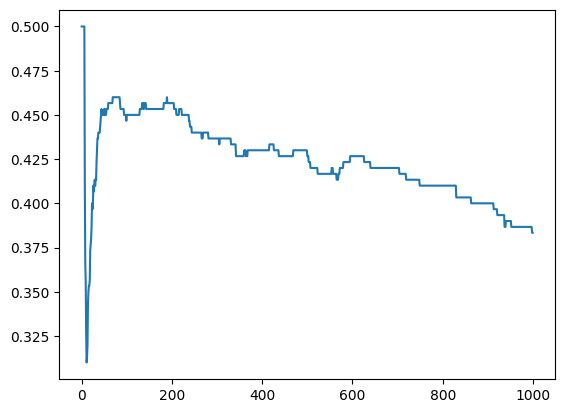

In [26]:
epoch = list(range(0,1000))
plt.plot(epoch, error)
